## Baseline-Modell

# Erstellt je User einen Case/Trace mit den dazugehörigen Events (Zustandsverläufen).
# Insgesamt 3 Zustände möglich.
Ob die Patienten Tinnitus hatten oder nicht, wird noch nicht beachtet.

In [68]:
import pandas as pd

In [69]:
# CSV laden
df = pd.read_csv('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-02 TYT_answers2.csv', sep=";")

# Überblick verschaffen

In [70]:
df.head()

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,notification_fixed,created_at,updated_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration
0,2959,1.0,6.0,4.0,5.0,3.0,8.0,3.0,1.0,-688.462,...,0,22.04.14 13:58,22.04.14 13:58,14.02.79,35,0.0,0.0,0.0,14.02.10,4
1,2998,1.0,5.0,5.0,5.0,5.0,7.0,8.0,1.0,-109.410,...,0,27.04.14 08:10,27.04.14 08:10,14.02.79,35,0.0,0.0,0.0,14.02.10,4
2,3002,0.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,-120.225,...,0,28.04.14 15:45,28.04.14 15:45,14.02.79,35,0.0,0.0,0.0,14.02.10,4
3,3003,0.0,8.0,7.0,3.0,6.0,5.0,6.0,1.0,-394.602,...,0,28.04.14 15:45,28.04.14 15:45,14.02.79,35,0.0,0.0,0.0,14.02.10,4
4,3054,0.0,NaN,1.0,NaN,NaN,NaN,NaN,0.0,-187.568,...,0,22.05.14 12:58,22.05.14 12:58,14.02.79,35,0.0,0.0,0.0,14.02.10,4


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112190 entries, 0 to 112189
Data columns (total 29 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  112190 non-null  int64  
 1   q1                  110565 non-null  float64
 2   q2                  110264 non-null  float64
 3   q3                  104169 non-null  float64
 4   q4                  109385 non-null  float64
 5   q5                  107775 non-null  float64
 6   q6                  103110 non-null  float64
 7   q7                  106857 non-null  float64
 8   q8                  108792 non-null  float64
 9   soundlevel          110045 non-null  float64
 10  sound_rounded       112190 non-null  int64  
 11  sound_env           110045 non-null  float64
 12  sound_env2          110045 non-null  str    
 13  user_id             112190 non-null  int64  
 14  user_os             112190 non-null  str    
 15  user_agent          112190 non-null  str    


In [72]:
df.describe(include="all")

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,notification_fixed,created_at,updated_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration
count,112190.000000,110565.000000,110264.000000,104169.000000,109385.000000,107775.000000,103110.000000,106857.000000,108792.000000,110045.000000,...,112190.000000,112190,112190,107193,110582,109714.000000,109641.000000,109756.000000,106169,110581
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,95272,95272,2880,84,NaN,NaN,NaN,1999,63
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,08.09.20 12:28,08.09.20 12:28,24.02.61,57,NaN,NaN,NaN,01.07.87,0
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,132,132,6815,7121,NaN,NaN,NaN,6817,20311
mean,60649.225689,0.800308,4.817883,3.754121,5.719943,2.546398,2.761643,5.929139,0.326982,701.249939,...,0.224610,NaN,NaN,NaN,NaN,0.206655,0.249368,0.370649,NaN,NaN
std,33379.682422,0.399771,3.137693,2.901579,2.199984,2.332471,2.445803,3.259860,0.469113,2517.894896,...,0.417327,NaN,NaN,NaN,NaN,0.404908,0.432649,0.686600,NaN,NaN
min,2959.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-998.378000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
25%,31524.250000,1.000000,2.000000,1.000000,5.000000,0.000000,1.000000,3.000000,0.000000,-355.795000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
50%,61250.500000,1.000000,4.000000,3.000000,5.000000,3.000000,2.000000,6.000000,0.000000,0.000000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
75%,89622.750000,1.000000,7.000000,6.000000,8.000000,4.000000,4.000000,9.000000,1.000000,436.000000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN


In [73]:
# Einzigartige Fälle
print("Anzahl Cases:", df["id"].nunique())

Anzahl Cases: 112184


In [74]:
# Einzigartige User
print("Anzahl User:", df["user_id"].nunique())

Anzahl User: 3339


In [75]:
# Einträge je User
print(f"Durchschnittliche Einträge pro User: {112184/3339:.2f}")

Durchschnittliche Einträge pro User: 33.60


In [76]:
# Fehlende Werte finden
df.isna().sum()

id                        0
q1                     1625
q2                     1926
q3                     8021
q4                     2805
q5                     4415
q6                     9080
q7                     5333
q8                     3398
soundlevel             2145
sound_rounded             0
sound_env              2145
sound_env2             2145
user_id                   0
user_os                   0
user_agent                0
save_date                 0
autosaved                 0
notification_date     92969
notification_fixed        0
created_at                0
updated_at                0
date_of_birth2         4997
age                    1608
famhistory             2476
gender                 2549
handedness             2434
onset_date2            6021
onset_duration         1609
dtype: int64

# Aufräumen

In [77]:
# Schauen, ob zwei Spalten redundante Inhalte haben
# bei True sind die Inhalte 1:1 gleich
df["created_at"].equals(df["updated_at"])

True

In [78]:
# Schauen, ob die Infos in der Spalte überhaupt relevant sind
df["user_agent"]

0         TrackYourTinnitus/1.1.1 (iPhone; iOS 7.1; Scal...
1         TrackYourTinnitus/1.1.1 (iPhone; iOS 7.1.1; Sc...
2         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
3         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
4         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
                                ...                        
112185    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 16.3.1;...
112186    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 16.7.5;...
112187    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.4.1;...
112188    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.5.1;...
112189    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.5.1;...
Name: user_agent, Length: 112190, dtype: str

In [79]:
# Schauen, ob die Infos in der Spalte überhaupt relevant sind
df["autosaved"]

0         1
1         0
2         1
3         0
4         1
         ..
112185    0
112186    0
112187    0
112188    0
112189    0
Name: autosaved, Length: 112190, dtype: int64

In [80]:
# Spalten "user_agent", "updated_at" und "autosaved" entfernen.
# zudem "notification_fixed" und "notification_date" entfernen, da Miriam sie für unwichtig erklärt hat
df = df.drop(columns=["user_agent", "updated_at", "autosaved", "notification_fixed", "notification_date"])

In [81]:
df.columns

Index(['id', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'soundlevel',
       'sound_rounded', 'sound_env', 'sound_env2', 'user_id', 'user_os',
       'save_date', 'created_at', 'date_of_birth2', 'age', 'famhistory',
       'gender', 'handedness', 'onset_date2', 'onset_duration'],
      dtype='str')

In [82]:
# Schauen, dass Werte von Q1-Q8 im erlaubten Bereich sind
# q1 und q8 (0 oder 1)
invalid_q1_q8 = df[
    (df["q1"] < 0) | (df["q1"] > 1) |
    (df["q8"] < 0) | (df["q8"] > 1)
]
print("q1/q8 Fehler:", len(invalid_q1_q8))

# q2 bis q7 (0–10)
invalid_q2_q7 = df[
    (df[["q2","q3","q4","q5","q6","q7"]] < 0).any(axis=1) |
    (df[["q2","q3","q4","q5","q6","q7"]] > 10).any(axis=1)
]
print("q2–q7 Fehler:", len(invalid_q2_q7))

q1/q8 Fehler: 0
q2–q7 Fehler: 0


In [83]:
# Schauen, dass "age" nicht <0 oder >110 ist
df["age"] = pd.to_numeric(df["age"], errors="coerce")
invalid_age = df[(df["age"] < 0) | (df["age"] > 110)]

print(invalid_age[["id", "user_id", "age"]])

          id  user_id    age
10948  12172      835  113.0


In [84]:
# Sicherstellen, dass "age" numerisch ist
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Alter und Onset_duration auf NaN setzen
df.loc[(df["user_id"] == 835) & ((df["age"] < 0) | (df["age"] > 110)), "age"] = pd.NA
df.loc[(df["user_id"] == 835), "onset_duration"] = pd.NA

# Kontrolle
df[df["user_id"] == 835]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,user_os,save_date,created_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration
10948,12172,1.0,9.0,10.0,0.0,0.0,9.0,5.0,1.0,909.0,...,Android,17.02.15 23:03,18.02.15 02:12,21.02.01,NaN,0.0,0.0,2.0,12.03.02,NaN


In [85]:
df.isna().sum()

id                   0
q1                1625
q2                1926
q3                8021
q4                2805
q5                4415
q6                9080
q7                5333
q8                3398
soundlevel        2145
sound_rounded        0
sound_env         2145
sound_env2        2145
user_id              0
user_os              0
save_date            0
created_at           0
date_of_birth2    4997
age               5611
famhistory        2476
gender            2549
handedness        2434
onset_date2       6021
onset_duration    1610
dtype: int64

## User mit nur einem Eintrag entfernen

In [87]:
'''
print(f"Anzahl einzigartiger Nutzer vor dem Entfernen: {df['user_id'].nunique()}")
# Behalte nur die user_id's, die mehr als einen Eintrag haben
df = df.groupby("user_id").filter(lambda x: len(x) > 1)

# Optional: Index zurücksetzen nach dem Löschen
#df = df.reset_index(drop=True)

# Kurze Kontrolle
print(f"Verbleibende Einträge: {len(df)}")
print(f"Anzahl einzigartiger Nutzer nach dem Entfernen: {df['user_id'].nunique()}")
print(f"Entfernte Nutzer: {3339-df['user_id'].nunique()}")
'''

Verbleibende Einträge: 111172
Anzahl einzigartiger Nutzer: 2321
Entfernte Nutzer: 1018


## Missing Data Strategie fahren

In [88]:
# für uns wäre es meiner Meinung nach wichtig, Missing Data bei q1-q8 zu korrigieren.
# am wichtigsten ist eigentlich q1. Wenn's nicht ausgefüllt ist, dann ... machen.

'''
# Löschen von Zeilen mit fehlenden q1 Werten
df = df.dropna(subset=["q1"])
'''

'''
# Fehlende q1 Werte mit dem Mittelwert ersetzen
import numpy as np
# Mittelwert berechnen und aufrunden
mean_val = df["q1"].mean()
rounded_val = int(np.ceil(mean_val)) # aus 0.80 wird 1
# Fehlende Werte ersetzen
df["q1"] = df["q1"].fillna(rounded_val)
print(f"Eingesetzter Mittelwert: {rounded_val}")
'''

'''
# Fehlende q1 Werte mit dem Median ersetzen
# Median berechnen
median_q1 = df["q1"].median()
# Fehlende Werte ersetzen
df["q1"] = df["q1"].fillna(median_q1)
print(f"Eingesetzter Median: {median_q1}")
'''

'''
# Fehlende q1 Werte mit kNN=5 ersetzen
from sklearn.impute import KNNImputer

# 1. Spalten auswählen, die für die Ähnlichkeit relevant sind
impute_cols = ["q1", "sound_env", "age", "gender"]

# Falls gender/sound_env Text sind, müssen sie in Zahlen umgewandelt werden (Faktorisiert)
df_impute = df[impute_cols].copy()

# Beispiel für kategorische Daten (falls nötig):
for col in df_impute.select_dtypes(include=['object']).columns:
    df_impute[col] = pd.factorize(df_impute[col])[0]

# 2. KNN Imputer konfigurieren (=5)
imputer = KNNImputer(n_neighbors=5)

# 3. Fehlende Werte schätzen
df_filled = imputer.fit_transform(df_impute)

# 4. Den Wert zurück in den originalen DataFrame schreiben
df["q1"] = df_filled[:, 0] # q1 ist die erste Spalte (Index 0)

# 5. Ergebnis auf 0 oder 1 runden
df["q1"] = df["q1"].round().astype(int)
'''

'\n# Fehlende q1 Werte mit kNN=5 ersetzen\nfrom sklearn.impute import KNNImputer\n\n# 1. Spalten auswählen, die für die Ähnlichkeit relevant sind\nimpute_cols = ["q1", "sound_env", "age", "gender"]\n\n# Falls gender/sound_env Text sind, müssen sie in Zahlen umgewandelt werden (Faktorisiert)\ndf_impute = df[impute_cols].copy()\n\n# Beispiel für kategorische Daten (falls nötig):\nfor col in df_impute.select_dtypes(include=[\'object\']).columns:\n    df_impute[col] = pd.factorize(df_impute[col])[0]\n\n# 2. KNN Imputer konfigurieren (=5)\nimputer = KNNImputer(n_neighbors=5)\n\n# 3. Fehlende Werte schätzen\ndf_filled = imputer.fit_transform(df_impute)\n\n# 4. Den Wert zurück in den originalen DataFrame schreiben\ndf["q1"] = df_filled[:, 0] # q1 ist die erste Spalte (Index 0)\n\n# 5. Ergebnis auf 0 oder 1 runden\ndf["q1"] = df["q1"].round().astype(int)\n'

In [89]:
# Kontrolle ob q1 noch fehlende Werte hat
df.isna().sum()

id                   0
q1                1615
q2                1898
q3                7973
q4                2787
q5                4389
q6                9027
q7                5296
q8                3351
soundlevel        2144
sound_rounded        0
sound_env         2144
sound_env2        2144
user_id              0
user_os              0
save_date            0
created_at           0
date_of_birth2    4961
age               5564
famhistory        2452
gender            2525
handedness        2409
onset_date2       5959
onset_duration    1597
dtype: int64

# Daten aufbereiten

In [90]:
# Zeitspalten konvertieren
time_cols = ["save_date", "created_at"]

for col in time_cols:
    df[col] = pd.to_datetime(df[col], format="%d.%m.%y %H:%M", errors="coerce")

# Geburtsdatum
date_cols = ["date_of_birth2", "onset_date2"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d.%m.%y", errors="coerce")

In [91]:
df[df["created_at"].isna()]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,user_os,save_date,created_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration


In [92]:
df[df["save_date"].isna()]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,user_os,save_date,created_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration
2633,3189,0.0,8.0,4.0,4.0,5.0,2.0,9.0,1.0,NaN,...,iOS,NaT,2014-07-07 08:06:00,NaT,NaN,0.0,0.0,1.0,NaT,#WERT!
2634,3190,1.0,7.0,5.0,NaN,NaN,NaN,NaN,0.0,-425.513,...,iOS,NaT,2014-07-07 08:06:00,NaT,NaN,0.0,0.0,1.0,NaT,#WERT!
2635,3191,1.0,6.0,4.0,4.0,NaN,NaN,NaN,0.0,NaN,...,iOS,NaT,2014-07-07 08:06:00,NaT,NaN,0.0,0.0,1.0,NaT,#WERT!
2636,3192,1.0,5.0,2.0,4.0,5.0,2.0,7.0,1.0,-350.426,...,iOS,NaT,2014-07-07 08:07:00,NaT,NaN,0.0,0.0,1.0,NaT,#WERT!
2637,3193,1.0,6.0,5.0,4.0,NaN,NaN,NaN,0.0,-539.439,...,iOS,NaT,2014-07-08 01:42:00,2059-01-27,NaN,1.0,0.0,0.0,1995-03-07,#WERT!
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110295,110864,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,iOS,NaT,2022-02-13 04:55:00,1975-03-09,NaN,0.0,1.0,2.0,2009-01-06,#WERT!
110296,110865,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,iOS,NaT,2022-02-13 04:55:00,1975-03-09,NaN,0.0,1.0,2.0,2009-01-06,#WERT!
110297,110866,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,iOS,NaT,2022-02-13 04:55:00,1975-03-09,NaN,0.0,1.0,2.0,2009-01-06,#WERT!
110298,110867,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,iOS,NaT,2022-02-13 04:55:00,1975-03-09,NaN,0.0,1.0,2.0,2009-01-06,#WERT!


In [93]:
# Spalte "save_date" entfernen. Wir werden "created_at" als Zeitstempel nehmen
df = df.drop(columns=["save_date"])

In [94]:
# Änderungen kontrollieren
df.head()

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,user_id,user_os,created_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration
0,2959,1.0,6.0,4.0,5.0,3.0,8.0,3.0,1.0,-688.462,...,66,iOS,2014-04-22 13:58:00,1979-02-14,35.0,0.0,0.0,0.0,2010-02-14,4
1,2998,1.0,5.0,5.0,5.0,5.0,7.0,8.0,1.0,-109.410,...,66,iOS,2014-04-27 08:10:00,1979-02-14,35.0,0.0,0.0,0.0,2010-02-14,4
2,3002,0.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,-120.225,...,66,iOS,2014-04-28 15:45:00,1979-02-14,35.0,0.0,0.0,0.0,2010-02-14,4
3,3003,0.0,8.0,7.0,3.0,6.0,5.0,6.0,1.0,-394.602,...,66,iOS,2014-04-28 15:45:00,1979-02-14,35.0,0.0,0.0,0.0,2010-02-14,4
4,3054,0.0,NaN,1.0,NaN,NaN,NaN,NaN,0.0,-187.568,...,66,iOS,2014-05-22 12:58:00,1979-02-14,35.0,0.0,0.0,0.0,2010-02-14,4


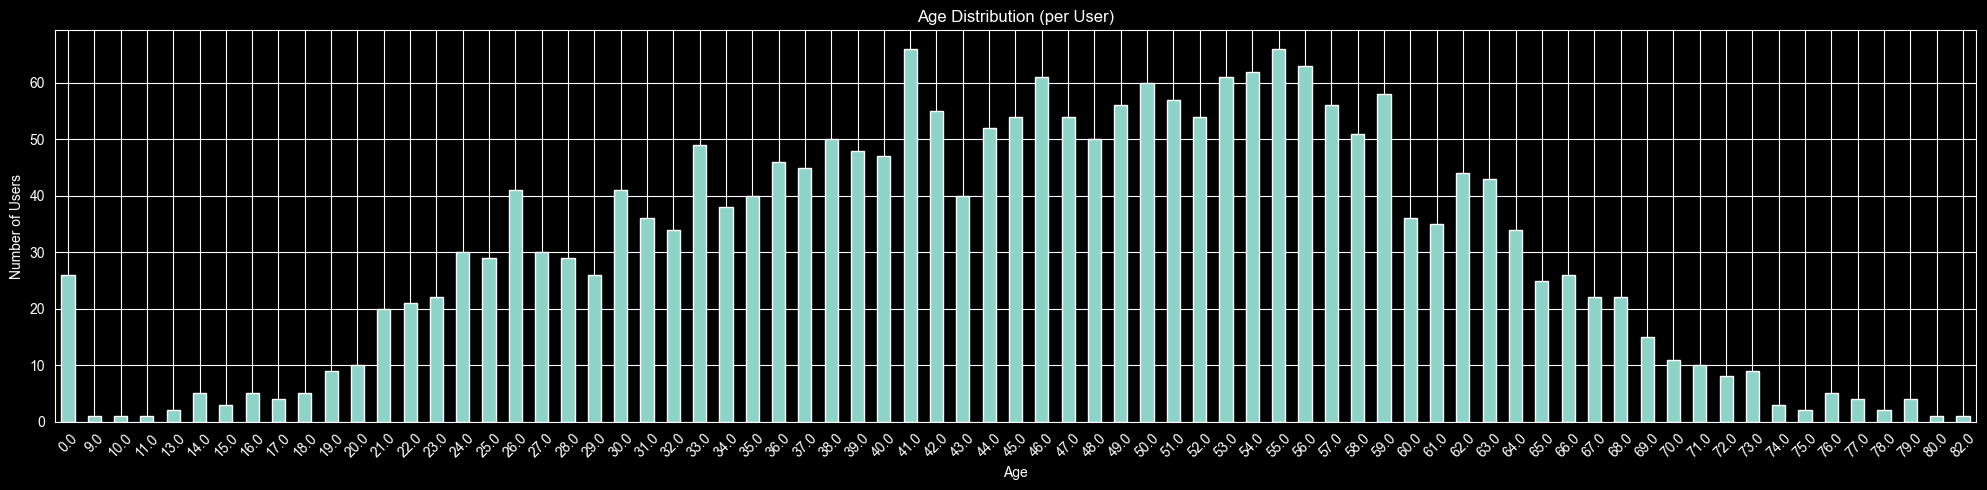

In [95]:
import matplotlib.pyplot as plt

# pro User genau ein Eintrag (z. B. erster Eintrag)
df_user = df.drop_duplicates(subset="user_id")

plt.figure(figsize=(20,5))

df_user["age"].value_counts().sort_index().plot(kind="bar")

plt.title("Age Distribution (per User)")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Vorbereitung des Dataframes auf die PM4Py Analyse

In [96]:
# Score berechnen (ohne q1 und q8)
df["score"] = df[["q2","q3","q4","q5","q6","q7"]].sum(axis=1)

# Kategorien definieren
def categorize(score):
    if score <= 20:
        return "low"
    elif score <= 40:
        return "medium"
    else:
        return "high"

df["concept:name"] = df["score"].apply(categorize)

In [97]:
# Case = Patient
df_event = df.rename(columns={
    "user_id": "case:concept:name",
    "created_at": "time:timestamp"
})

# Datentypen fixen
df_event["case:concept:name"] = df_event["case:concept:name"].astype(str)
df_event["concept:name"] = df_event["concept:name"].astype(str)

# Datentypen Kontrollieren
print(df_event["case:concept:name"].dtype)
print(df_event["concept:name"].dtype)

# Sortieren nach Zeit
df_event = df_event.sort_values(
    by=["case:concept:name", "time:timestamp"]
)

# Relevante Spalten behalten
df_event = df_event[[
    "case:concept:name",
    "concept:name",
    "time:timestamp",
    "age",
    "gender",
    "sound_env"
]]

df_event

str
str


,case:concept:name,concept:name,time:timestamp,age,gender,sound_env
13122,1000,medium,2015-04-14 13:43:00,38.0,0.0,0.000610
13123,1000,medium,2015-04-14 21:16:00,38.0,0.0,0.001312
13124,1000,medium,2015-04-15 09:39:00,38.0,0.0,0.002045
13125,1000,low,2015-04-15 13:16:00,38.0,0.0,0.001221
13126,1000,low,2015-04-20 21:09:00,38.0,0.0,0.000427
...,...,...,...,...,...,...
13115,996,high,2015-04-09 06:04:00,48.0,0.0,0.002090
13116,997,medium,2015-04-08 22:55:00,30.0,0.0,0.000507
13117,997,medium,2015-04-09 07:17:00,30.0,0.0,0.000655
13118,997,low,2015-04-09 16:48:00,30.0,0.0,0.007934


In [98]:
# Personen je Level
df_event.groupby("concept:name")["case:concept:name"].nunique()

concept:name
high       416
low       1555
medium    2175
Name: case:concept:name, dtype: int64

In [99]:
# Traces je Level
df_event.groupby("concept:name")["concept:name"].count()

concept:name
high       3534
low       34784
medium    72854
Name: concept:name, dtype: int64

In [100]:
# Personen, die nur einen Eintrag geleistet haben
(df_event["case:concept:name"].value_counts() == 1).sum()

np.int64(0)

In [101]:
# Personen, die nur einen Eintrag geleistet haben in %
(1018/3339)*100

30.48817011081162

In [102]:
# oder das
# hier viel weniger Attribute mitgenommen
'''
question_cols = ["q1","q2","q3","q4","q5","q6","q7","q8"]

df_event = df.melt(
id_vars=["id", "created_at"],
value_vars=question_cols,
var_name="concept:name",
value_name="value"
)

# Spalten für PM4Py umbenennen
df_event = df_event.rename(columns={
"id": "case:concept:name",
"created_at": "time:timestamp"
})

df_event.head()
'''

'\nquestion_cols = ["q1","q2","q3","q4","q5","q6","q7","q8"]\n\ndf_event = df.melt(\nid_vars=["id", "created_at"],\nvalue_vars=question_cols,\nvar_name="concept:name",\nvalue_name="value"\n)\n\n# Spalten für PM4Py umbenennen\ndf_event = df_event.rename(columns={\n"id": "case:concept:name",\n"created_at": "time:timestamp"\n})\n\ndf_event.head()\n'

In [103]:
df_event[df_event["time:timestamp"].isna()]

,case:concept:name,concept:name,time:timestamp,age,gender,sound_env


In [104]:
# Kontrollieren, dass jetzt die Sortierung nach Case und timestamp sortiert ist
df_event.head(20)

,case:concept:name,concept:name,time:timestamp,age,gender,sound_env
13122,1000,medium,2015-04-14 13:43:00,38.0,0.0,0.000610
13123,1000,medium,2015-04-14 21:16:00,38.0,0.0,0.001312
13124,1000,medium,2015-04-15 09:39:00,38.0,0.0,0.002045
13125,1000,low,2015-04-15 13:16:00,38.0,0.0,0.001221
13126,1000,low,2015-04-20 21:09:00,38.0,0.0,0.000427
13127,1000,medium,2015-04-25 22:19:00,38.0,0.0,0.000824
13128,1000,low,2015-05-06 11:54:00,38.0,0.0,0.001282
13129,1000,low,2015-07-14 12:00:00,39.0,0.0,0.176550
13130,1000,low,2015-07-14 12:00:00,39.0,0.0,0.003113
13131,1000,low,2015-12-15 19:45:00,39.0,0.0,0.001862


In [105]:
import pm4py
from pm4py.algo.filtering.log.variants import variants_filter

log = pm4py.convert_to_event_log(df_event)
print("Anzahl Traces:", len(log))

# Die Varianten (Traces) zählen
variants = pm4py.get_variants(log)

# Sortieren und die Top 100/x/1000 holen
filtered_log = pm4py.filter_variants_top_k(log, k=250)


Anzahl Traces: 2321


In [106]:
# euren gewünschten Pfad hernehmen. Dann auch hernehmen, um damit weiter zu arbeiten

pm4py.write_xes(log, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0.xes')
pm4py.write_xes(filtered_log, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0 filtered.xes')

exporting log, completed traces :: 100%|██████████| 1335/1335 [00:00<00:00, 3995.28it/s] 
